Practice for lab assignment 1.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cvxpy as cp

Writing down a function that defines f(x)<br>

In [2]:
def func(x,k):
        return 0.5 * np.sum(x[:-1]**2) + 0.5 * k * x[-1]**2

Generating a random vector<br>

In [3]:
x_bef = np.random.normal(0,1,100)

In [4]:
x_bef

array([-1.20728157, -1.49928649,  0.2586898 , -1.6630963 ,  1.14214547,
       -1.20329963, -0.78744576,  0.36743049,  0.43401363,  1.06488056,
       -0.61633146, -0.64679232,  1.00109949,  1.23295453, -0.38631065,
        0.46647782,  2.56152361,  1.01949729, -0.92491477,  0.88272   ,
       -0.83278854, -0.0344085 ,  0.37352641,  1.55190439, -0.18709312,
       -0.01024987, -0.18104112, -0.22479243,  0.60663437, -0.55307392,
       -0.42621359,  1.64356871,  0.26402601,  0.49927396,  0.6439252 ,
       -0.08602899, -2.03802012, -0.09884744, -0.07139861,  0.73225655,
        0.78463253,  0.08384998, -0.10724075, -0.15259654,  0.61778352,
       -0.16112993, -1.32236103, -0.03048557,  0.94393305, -1.16567494,
        0.42115908,  0.19316172,  0.65156729, -0.14765538,  1.27575943,
       -0.49359535, -0.97521626, -1.23313228,  0.31921913,  0.80791506,
       -0.84989552, -0.87109692,  0.68451237, -1.33412348,  0.22770012,
        0.4636336 ,  0.8497436 ,  1.09578978, -0.17091877, -0.29

Finding out the optimal value of x and the function using cvxpy<br>

In [5]:
k = 5
n = 100

In [6]:
x_star = cp.Variable(n)
objective = cp.Minimize(
    0.5 * cp.sum_squares(x_star[:-1]) + 0.5 * k * cp.square(x_star[-1])
)
prob = cp.Problem(objective)
prob.solve()
x_optimal = x_star.value
f_star = prob.value
print("Optimal x : " ,x_optimal)
print("Optimal function value : ",f_star)

Optimal x :  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0.]
Optimal function value :  0.0


Defining a function that calculates the gradient of the given function<br>

In [7]:
def gradient(x,k):
    n = x.shape[0]
    p=x.copy()
    p[-1] *= k
    return p

Verifying if our gradient function works well for the random generated x vector<br>

In [8]:
gradient(x_bef,5)

array([-1.20728157, -1.49928649,  0.2586898 , -1.6630963 ,  1.14214547,
       -1.20329963, -0.78744576,  0.36743049,  0.43401363,  1.06488056,
       -0.61633146, -0.64679232,  1.00109949,  1.23295453, -0.38631065,
        0.46647782,  2.56152361,  1.01949729, -0.92491477,  0.88272   ,
       -0.83278854, -0.0344085 ,  0.37352641,  1.55190439, -0.18709312,
       -0.01024987, -0.18104112, -0.22479243,  0.60663437, -0.55307392,
       -0.42621359,  1.64356871,  0.26402601,  0.49927396,  0.6439252 ,
       -0.08602899, -2.03802012, -0.09884744, -0.07139861,  0.73225655,
        0.78463253,  0.08384998, -0.10724075, -0.15259654,  0.61778352,
       -0.16112993, -1.32236103, -0.03048557,  0.94393305, -1.16567494,
        0.42115908,  0.19316172,  0.65156729, -0.14765538,  1.27575943,
       -0.49359535, -0.97521626, -1.23313228,  0.31921913,  0.80791506,
       -0.84989552, -0.87109692,  0.68451237, -1.33412348,  0.22770012,
        0.4636336 ,  0.8497436 ,  1.09578978, -0.17091877, -0.29

In [9]:
x = x_bef * 100

Defining a function that calculates the Hessian of the given function<br>

In [10]:
def hessian(x,k):
    n = x.shape[0]
    p = np.zeros((n,n))
    for i in range(n):
        for j in range(n):
            if (i==j and i!=n-1):
                p[i][j] = 1

    p[n-1,n-1] = k
    return p

Verifying if our hessian function works well for the random generated x vector<br>

In [11]:
hessian(x,k)

array([[1., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 0., 5.]], shape=(100, 100))

Checking whether the function is convex or not<br>

In [12]:
def is_convex(x,k,tol=1e-8):
    H = hessian(x,k)
    eig_min = min(np.linalg.eigvals(H))
    if(eig_min >= -tol):
        return True
    return False

In [13]:
is_convex(x,k)

True

So the function we are handling here is convex <br>

Checking for Beta - smooth<br>

In [14]:
def beta_smooth(x,k):
    H = hessian(x,k)
    beta = np.max(np.linalg.eigvals(H))
    return beta

In [15]:
beta = beta_smooth(x,k)
print(beta)

5.0


Checking for alpha-smooth <br>

In [16]:
def alpha_smooth(x,k):
    H = hessian(x,k)
    alpha = np.min(np.linalg.eigvals(H))
    return alpha

In [17]:
alpha = alpha_smooth(x,k)
print(alpha)

1.0


We will use that randomly generated vector multiplied by 100 in our assignment <br>

The x0 mentioned in the lab module is named as x in my assignment for simplicity<br>

In [18]:
x

array([-120.7281574 , -149.92864946,   25.86898009, -166.30963025,
        114.214547  , -120.32996268,  -78.74457647,   36.74304869,
         43.40136342,  106.48805569,  -61.6331459 ,  -64.67923156,
        100.10994938,  123.29545286,  -38.63106501,   46.64778158,
        256.152361  ,  101.94972901,  -92.49147655,   88.27200037,
        -83.27885446,   -3.44084953,   37.35264054,  155.19043943,
        -18.70931212,   -1.0249867 ,  -18.10411169,  -22.47924322,
         60.66343741,  -55.30739197,  -42.6213591 ,  164.35687093,
         26.40260109,   49.92739621,   64.39252044,   -8.6028988 ,
       -203.80201238,   -9.88474382,   -7.13986115,   73.22565477,
         78.46325283,    8.38499796,  -10.72407474,  -15.25965373,
         61.77835153,  -16.1129932 , -132.23610317,   -3.04855735,
         94.3933051 , -116.56749361,   42.11590768,   19.31617179,
         65.15672865,  -14.76553809,  127.57594334,  -49.35953505,
        -97.52162635, -123.3132278 ,   31.92191324,   80.79150

In [19]:
T = 200

Defining a function for gradient descent algorithm<br>

In [20]:
def gradient_descent(x,T,eta,k):
    p = x.copy()
    # recording the function values after each iteration of the gradient descent algorithm
    f_gd = np.zeros(T)
    for i in range(T):
        p = p - eta * gradient(p,k)
        f_gd[i] = func(p,k)
    return p , f_gd


In [21]:
eta = 0.2
x_gd , f_gd = gradient_descent(x,T,eta,k)

In [22]:
x_gd

array([-5.00963369e-18, -6.22131265e-18,  1.07343736e-18, -6.90104400e-18,
        4.73935041e-18, -4.99311054e-18, -3.26751846e-18,  1.52465853e-18,
        1.80094633e-18,  4.41873845e-18, -2.55747698e-18, -2.68387478e-18,
        4.15407794e-18,  5.11616401e-18, -1.60300206e-18,  1.93565696e-18,
        1.06290821e-17,  4.23041988e-18, -3.83794822e-18,  3.66286040e-18,
       -3.45566903e-18, -1.42778587e-19,  1.54995363e-18,  6.43965145e-18,
       -7.76345819e-19, -4.25319828e-20, -7.51232933e-19, -9.32779697e-19,
        2.51723878e-18, -2.29498884e-18, -1.76857993e-18,  6.82001395e-18,
        1.09558004e-18,  2.07174508e-18,  2.67197766e-18, -3.56978625e-19,
       -8.45679623e-18, -4.10168984e-19, -2.96269650e-19,  3.03850995e-18,
        3.25584489e-18,  3.47936796e-19, -4.44997151e-19, -6.33201707e-19,
        2.56350231e-18, -6.68611162e-19, -5.48715769e-18, -1.26500362e-19,
        3.91686489e-18, -4.83698630e-18,  1.74760615e-18,  8.01527556e-19,
        2.70368860e-18, -

The results from the gradient descent converge completely to the optimal solution<br>

In [23]:
f_gd

array([3.37698418e+05, 2.16126987e+05, 1.38321272e+05, 8.85256140e+04,
       5.66563929e+04, 3.62600915e+04, 2.32064585e+04, 1.48521335e+04,
       9.50536542e+03, 6.08343387e+03, 3.89339768e+03, 2.49177451e+03,
       1.59473569e+03, 1.02063084e+03, 6.53203738e+02, 4.18050392e+02,
       2.67552251e+02, 1.71233441e+02, 1.09589402e+02, 7.01372173e+01,
       4.48878191e+01, 2.87282042e+01, 1.83860507e+01, 1.17670724e+01,
       7.53092636e+00, 4.81979287e+00, 3.08466744e+00, 1.97418716e+00,
       1.26347978e+00, 8.08627061e-01, 5.17521319e-01, 3.31213644e-01,
       2.11976732e-01, 1.35665109e-01, 8.68256695e-02, 5.55684285e-02,
       3.55637942e-02, 2.27608283e-02, 1.45669301e-02, 9.32283528e-03,
       5.96661458e-03, 3.81863333e-03, 2.44392533e-03, 1.56411221e-03,
       1.00103182e-03, 6.40660362e-04, 4.10022632e-04, 2.62414484e-04,
       1.67945270e-04, 1.07484973e-04, 6.87903826e-05, 4.40258448e-05,
       2.81765407e-05, 1.80329860e-05, 1.15411111e-05, 7.38631108e-06,
      

The function attains it's optimal value which is converged very accurately as 1e-13 is almost zero and this signifies that gradient descent converges accurately <br> 

Defining a function for accelerated gradient descent algorithm<br>

In [24]:
def accelerated_gradient_descent(x,T,beta,k):
    y=x.copy()
    p=x.copy()
    f_agd = np.zeros(T)
    cons = ((np.sqrt(k)-1)/(np.sqrt(k)+1))
    for i in range(T):
        y_prev = y.copy()
        y = p - (1/beta) * gradient(p,k)
        p = (1+cons) * y - cons * y_prev
        f_agd[i] = func(p,k)

    return p , f_agd 

In [25]:
x_agd , f_agd = accelerated_gradient_descent(x,T,beta,k)

In [26]:
x_agd

array([-2.46185443e-48, -3.05730260e-48,  5.27512924e-49, -3.39133893e-48,
        2.32903073e-48, -2.45373456e-48, -1.60573713e-48,  7.49253854e-49,
        8.85028324e-49,  2.17147431e-48, -1.25680567e-48, -1.31892059e-48,
        2.04141377e-48,  2.51420599e-48, -7.87753749e-49,  9.51228365e-49,
        5.22338648e-48,  2.07893003e-48, -1.88606002e-48,  1.80001766e-48,
       -1.69819884e-48, -7.01648303e-50,  7.61684479e-49,  3.16459954e-48,
       -3.81515000e-49, -2.09012389e-50, -3.69173924e-49, -4.58390368e-49,
        1.23703165e-48, -1.12781269e-48, -8.69122697e-49,  3.35151881e-48,
        5.38394372e-49,  1.01810534e-48,  1.31307406e-48, -1.75427878e-49,
       -4.15587298e-48, -2.01566900e-49, -1.45594029e-49,  1.49319684e-48,
        1.60000045e-48,  1.70984506e-49, -2.18682298e-49, -3.11170542e-49,
        1.25976667e-48, -3.28571599e-49, -2.69652121e-48, -6.21653191e-50,
        1.92484157e-48, -2.37701135e-48,  8.58815675e-49,  3.93889910e-49,
        1.32865758e-48, -

This clearly shows that the accelerated gradient descent converges exactly <br>

In [27]:
f_agd

array([2.80646066e+05, 1.28989318e+05, 5.59087240e+04, 2.30026506e+04,
       9.10598975e+03, 3.49926038e+03, 1.31335777e+03, 4.83570888e+02,
       1.75238651e+02, 6.26583310e+01, 2.21490782e+01, 7.75239800e+00,
       2.69008923e+00, 9.26394711e-01, 3.16881425e-01, 1.07741171e-01,
       3.64347714e-02, 1.22610231e-02, 4.10779904e-03, 1.37067088e-03,
       4.55666331e-04, 1.50966539e-04, 4.98596843e-05, 1.64193346e-05,
       5.39249660e-06, 1.76658311e-06, 5.77379661e-07, 1.88294780e-07,
       6.12807954e-08, 1.99055532e-08, 6.45412602e-09, 2.08910018e-09,
       6.75120391e-10, 2.17841907e-10, 7.01899539e-11, 2.25846919e-11,
       7.25753245e-12, 2.32930908e-12, 7.46713999e-13, 2.39108173e-13,
       7.64838567e-14, 2.44399970e-14, 7.80203593e-15, 2.48833211e-15,
       7.92901736e-16, 2.52439321e-16, 8.03038309e-17, 2.55253248e-17,
       8.10728340e-18, 2.57312596e-18, 8.16094035e-19, 2.58656876e-19,
       8.19262579e-20, 2.59326866e-20, 8.20364248e-21, 2.59364056e-21,
      

Also the function nears its optimal value as per iterations and at the end it attains its optimal value <br>

Defining a function for momentum gradient descent algorithm <br>

In [28]:
myu = [0.4,0.6,0.8]

In [29]:
def momentum_gradient_descent(x,T,beta,k,mu):
    eta = 1/beta

    x_prev = x.copy()

    f_mgd = np.zeros(T)

    for _ in range(T):
        # f_mgd[_] = func(x,k)
        x_next = x - eta * gradient(x,k) + mu * (x-x_prev)
        
        x_prev = x
        x = x_next
        f_mgd[_] = func(x,k)

    return x , f_mgd

Just checking for one value of myu to verify if the algorithm converges or not <br>

In [30]:
x_mgd , f_mgd = momentum_gradient_descent(x,T,beta,k,0.4) 

In [31]:
x_mgd

array([-2.03922903e-38, -2.53245689e-38,  4.36955026e-39, -2.80914936e-38,
        1.92920711e-38, -2.03250309e-38, -1.33008098e-38,  6.20629794e-39,
        7.33095925e-39,  1.79869832e-38, -1.04105043e-38, -1.09250211e-38,
        1.69096522e-38,  2.08259342e-38, -6.52520430e-39,  7.87931435e-39,
        4.32669016e-38,  1.72204108e-38, -1.56228098e-38,  1.49100947e-38,
       -1.40666984e-38, -5.81196666e-40,  6.30926459e-39,  2.62133421e-38,
       -3.16020498e-39, -1.73131329e-40, -3.05798008e-39, -3.79698707e-39,
        1.02467101e-38, -9.34201611e-39, -7.19920809e-39,  2.77616514e-38,
        4.45968461e-39,  8.43327670e-39,  1.08765925e-38, -1.45312256e-39,
       -3.44243620e-38, -1.66964004e-39, -1.20599970e-39,  1.23686043e-38,
        1.32532912e-38,  1.41631676e-39, -1.81141210e-39, -2.57752040e-39,
        1.04350311e-38, -2.72165866e-39, -2.23361067e-38, -5.14934278e-40,
        1.59440492e-38, -1.96895092e-38,  7.11383188e-39,  3.26271013e-39,
        1.10056755e-38, -

This clearly shows that momentum gradient method also converges nearly in the powers of 1e-40<br>

In [32]:
f_mgd

array([3.37698418e+05, 1.70256894e+05, 6.61439607e+04, 2.10454004e+04,
       5.30696598e+03, 7.37310038e+02, 6.63062132e+01, 4.09357109e+01,
       7.55367004e+01, 6.69742998e+01, 3.79432881e+01, 1.81019986e+01,
       6.72560130e+00, 2.01124588e+00, 4.72805255e-01, 5.34122888e-02,
       4.83428619e-03, 7.15637790e-03, 9.87275011e-03, 7.89122190e-03,
       4.20778670e-03, 1.90262861e-03, 6.75786648e-04, 1.89064788e-04,
       4.10729621e-05, 3.52963967e-06, 4.98690103e-07, 1.12367349e-06,
       1.25220534e-06, 9.13918585e-07, 4.60869618e-07, 1.97696458e-07,
       6.70676189e-08, 1.74493500e-08, 3.46382167e-09, 2.03562527e-10,
       7.38794190e-11, 1.63716658e-10, 1.54818088e-10, 1.04206742e-10,
       4.98799598e-11, 2.03056066e-11, 6.56983291e-12, 1.57726237e-12,
       2.81959108e-13, 9.59079938e-15, 1.23124615e-14, 2.25760782e-14,
       1.87229071e-14, 1.17124376e-14, 5.33643164e-15, 2.06111008e-15,
       6.34687164e-16, 1.39176784e-16, 2.19912094e-17, 4.00177617e-19,
      

The function evaluated at each iterations also converge to the optimal values 1e-74<br>

In [33]:
x_mgd_0_4 , f_mgd_0_4 = momentum_gradient_descent(x,T,beta,k,0.4)
x_mgd_0_6 , f_mgd_0_6 = momentum_gradient_descent(x,T,beta,k,0.6)
x_mgd_0_8 , f_mgd_0_8 = momentum_gradient_descent(x,T,beta,k,0.8)

We need to calculate the upper bound from theorem 3 and theorem 5 and plot them too<br>

In [34]:
time_array = np.arange(T)+1

In [35]:
gamma_5 = 1/(np.sqrt(k)-1)
gamma_3 = 1/(np.sqrt(k)-1)

In [36]:
upper_bound_thm3 = np.exp((-time_array)/k) * func(x,k)
upper_bound_thm5 = (1+gamma_5) ** (-time_array) *((alpha+beta)/2) 

Plotting f(x_t_gd) , f(x_t_agd) , f(x_t_mgd) versus time or we can say iterates(T) <br>

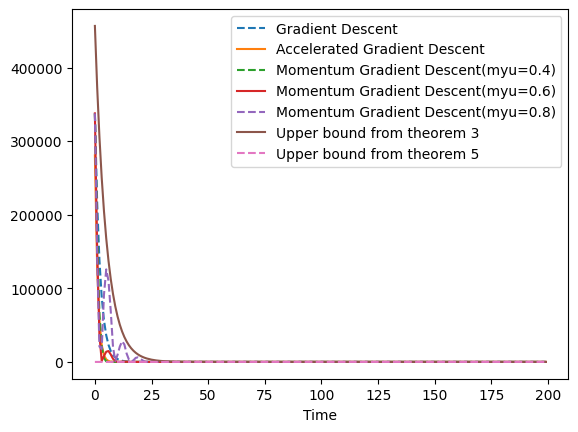

In [37]:
plt.plot(f_gd,label="Gradient Descent",color='#1f77b4',linestyle='--')
plt.plot(f_agd,label="Accelerated Gradient Descent" ,color='#ff7f0e',linestyle = 'solid')
plt.plot(f_mgd_0_4,label="Momentum Gradient Descent(myu=0.4)" ,color='#2ca02c',linestyle='--')
plt.plot(f_mgd_0_6,label="Momentum Gradient Descent(myu=0.6)" ,color='#d62728',linestyle = 'solid')
plt.plot(f_mgd_0_8,label="Momentum Gradient Descent(myu=0.8)" ,color='#9467bd',linestyle='--')
plt.plot(upper_bound_thm3,label="Upper bound from theorem 3",color='#8c564b',linestyle='solid')
plt.plot(upper_bound_thm5,label="Upper bound from theorem 5",color='#e377c2',linestyle='--')
plt.legend()
plt.xlabel("Time")
plt.show()

Now plotting the log of the previously plotted curves

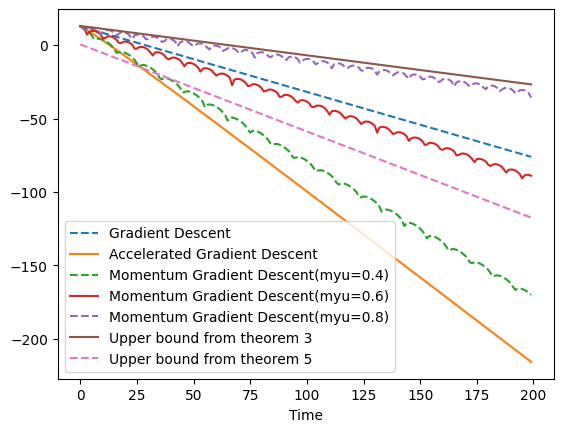

In [38]:
plt.plot(np.log(f_gd),label="Gradient Descent",color='#1f77b4',linestyle='--')
plt.plot(np.log(f_agd),label="Accelerated Gradient Descent" ,color='#ff7f0e',linestyle = 'solid')
plt.plot(np.log(f_mgd_0_4),label="Momentum Gradient Descent(myu=0.4)" ,color='#2ca02c',linestyle='--')
plt.plot(np.log(f_mgd_0_6),label="Momentum Gradient Descent(myu=0.6)" ,color='#d62728',linestyle = 'solid')
plt.plot(np.log(f_mgd_0_8),label="Momentum Gradient Descent(myu=0.8)" ,color='#9467bd',linestyle='--')
plt.plot(np.log(upper_bound_thm3),label="Upper bound from theorem 3",color='#8c564b',linestyle='solid')
plt.plot(np.log(upper_bound_thm5),label="Upper bound from theorem 5",color='#e377c2',linestyle='--')
plt.legend()
plt.xlabel("Time")
plt.show()

## Conclusion:<br>
1) From the non-log plot , all the methods eventually converge to the optimal solution confirming that the objective function is strongly convex and smooth. However the rates they converge with differ significantly :
<t>    -Gradient descent converges monotonically but slowly <br>
<t>    -Accelerated gradient descent converges the fastest <br>
<t>    -Momentum gradient descent shows intermediate behaviour depending upon the choice of parameter myu<br>
2) Comparison of convergence rates :<br>
<t>     AGD > MGD > GD <br>
3) Impact of parameter myu : <br>
<t>    -myu=0.4 provides modest acceleration over GD with stable behaviour and minimal oscillations<br>
<t>    -myu=0.6 achieves faster convergence than myu=0.4 , with noticeable but controlled oscillations<br>
<t>    -myu=0.8 shows fastest initial decrease among momentum variants, but also exhibits stronger oscillations, indicating reduced damping and potential instability<br>
4) The plotted theoretical upper bounds from Theorem 3 and Theorem 5 correctly upper-bound the empirical curves<br>

## k = 20

In [39]:
k=20
eta = 1/ beta_smooth(x,k)

In [40]:
beta = beta_smooth(x,k)
alpha = alpha_smooth(x,k)
eta = 1/beta

Defining the naming by adding _20 at the end of the previouse variables and recalculating the new ones <br>

In [41]:
x_gd_20 ,f_gd_20 = gradient_descent(x,T,eta,k)
x_agd_20 ,f_agd_20 = accelerated_gradient_descent(x,T,beta,k)
x_mgd_0_4_20, f_mgd_0_4_20 = momentum_gradient_descent(x,T,beta,k,0.4)
x_mgd_0_6_20 , f_mgd_0_6_20 = momentum_gradient_descent(x,T,beta,k,0.6)
x_mgd_0_8_20 , f_mgd_0_8_20 = momentum_gradient_descent(x,T,beta,k,0.8)
upper_bound_thm3_20 = np.exp((-time_array)/k) * func(x,k)
upper_bound_thm5_20 = (1+gamma_5) ** (-time_array) *((alpha+beta)/2) 

Plotting f(x_t_gd) , f(x_t_agd) , f(x_t_mgd) versus time or we can say iterates(T) <br>

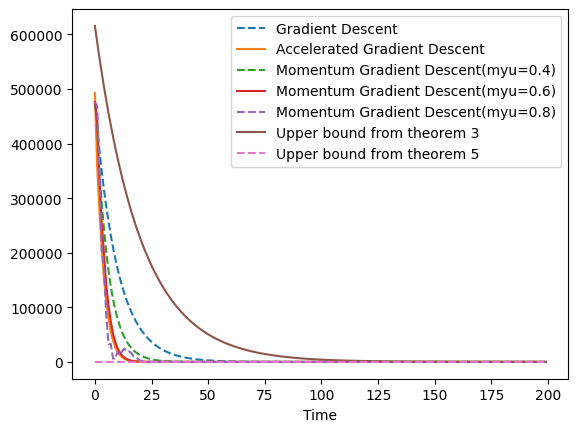

In [42]:
plt.plot(f_gd_20,label="Gradient Descent",color='#1f77b4',linestyle='--')
plt.plot(f_agd_20,label="Accelerated Gradient Descent" ,color='#ff7f0e',linestyle = 'solid')
plt.plot(f_mgd_0_4_20,label="Momentum Gradient Descent(myu=0.4)" ,color='#2ca02c',linestyle='--')
plt.plot(f_mgd_0_6_20,label="Momentum Gradient Descent(myu=0.6)" ,color='#d62728',linestyle = 'solid')
plt.plot(f_mgd_0_8_20,label="Momentum Gradient Descent(myu=0.8)" ,color='#9467bd',linestyle='--')
plt.plot(upper_bound_thm3_20,label="Upper bound from theorem 3",color='#8c564b',linestyle='solid')
plt.plot(upper_bound_thm5_20,label="Upper bound from theorem 5",color='#e377c2',linestyle='--')
plt.legend()
plt.xlabel("Time")
plt.show()

Now plotting the ones in log <br>

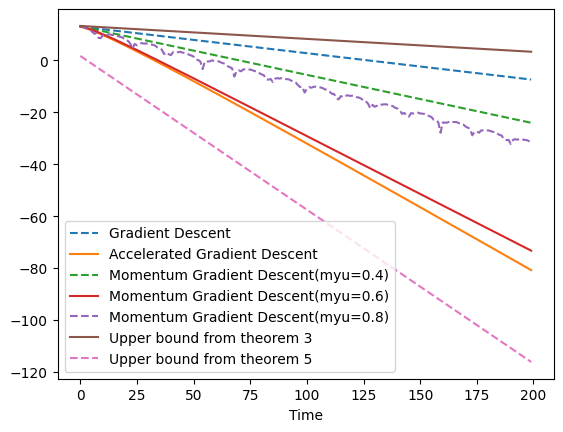

In [43]:
plt.plot(np.log(f_gd_20),label="Gradient Descent",color='#1f77b4',linestyle='--')
plt.plot(np.log(f_agd_20),label="Accelerated Gradient Descent" ,color='#ff7f0e',linestyle = 'solid')
plt.plot(np.log(f_mgd_0_4_20),label="Momentum Gradient Descent(myu=0.4)" ,color='#2ca02c',linestyle='--')
plt.plot(np.log(f_mgd_0_6_20),label="Momentum Gradient Descent(myu=0.6)" ,color='#d62728',linestyle = 'solid')
plt.plot(np.log(f_mgd_0_8_20),label="Momentum Gradient Descent(myu=0.8)" ,color='#9467bd',linestyle='--')
plt.plot(np.log(upper_bound_thm3_20),label="Upper bound from theorem 3",color='#8c564b',linestyle='solid')
plt.plot(np.log(upper_bound_thm5_20),label="Upper bound from theorem 5",color='#e377c2',linestyle='--')
plt.legend()
plt.xlabel("Time")
plt.show()

## k =50

In [44]:
k=50
eta = 1/ beta_smooth(x,k)

In [45]:
beta = beta_smooth(x,k)
alpha = alpha_smooth(x,k)
eta = 1/beta

Defining the naming by adding _50 at the end of the previouse variables and recalculating the new ones <br>

In [46]:
x_gd_50 ,f_gd_50 = gradient_descent(x,T,eta,k)
x_agd_50 ,f_agd_50 = accelerated_gradient_descent(x,T,beta,k)
x_mgd_0_4_50, f_mgd_0_4_50 = momentum_gradient_descent(x,T,beta,k,0.4)
x_mgd_0_6_50 , f_mgd_0_6_50 = momentum_gradient_descent(x,T,beta,k,0.6)
x_mgd_0_8_50 , f_mgd_0_8_50 = momentum_gradient_descent(x,T,beta,k,0.8)
upper_bound_thm3_50 = np.exp((-time_array)/k) * func(x,k)
upper_bound_thm5_50 = (1+gamma_5) ** (-time_array) *((alpha+beta)/2) 

Plotting f(x_t_gd) , f(x_t_agd) , f(x_t_mgd) versus time or we can say iterates(T) <br>

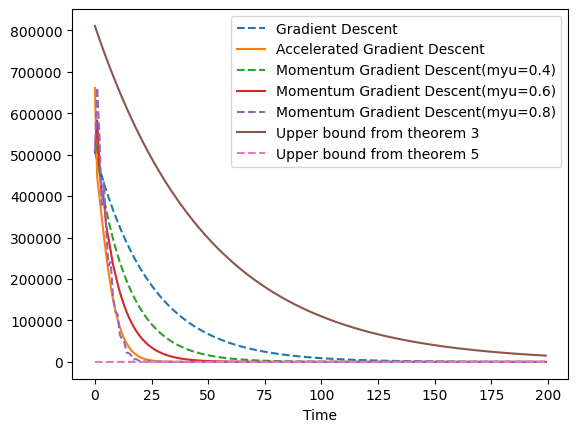

In [47]:
plt.plot(f_gd_50,label="Gradient Descent",color='#1f77b4',linestyle='--')
plt.plot(f_agd_50,label="Accelerated Gradient Descent" ,color='#ff7f0e',linestyle = 'solid')
plt.plot(f_mgd_0_4_50,label="Momentum Gradient Descent(myu=0.4)" ,color='#2ca02c',linestyle='--')
plt.plot(f_mgd_0_6_50,label="Momentum Gradient Descent(myu=0.6)" ,color='#d62728',linestyle = 'solid')
plt.plot(f_mgd_0_8_50,label="Momentum Gradient Descent(myu=0.8)" ,color='#9467bd',linestyle='--')
plt.plot(upper_bound_thm3_50,label="Upper bound from theorem 3",color='#8c564b',linestyle='solid')
plt.plot(upper_bound_thm5_50,label="Upper bound from theorem 5",color='#e377c2',linestyle='--')
plt.legend()
plt.xlabel("Time")
plt.show()

Now plotting the ones in log <br>

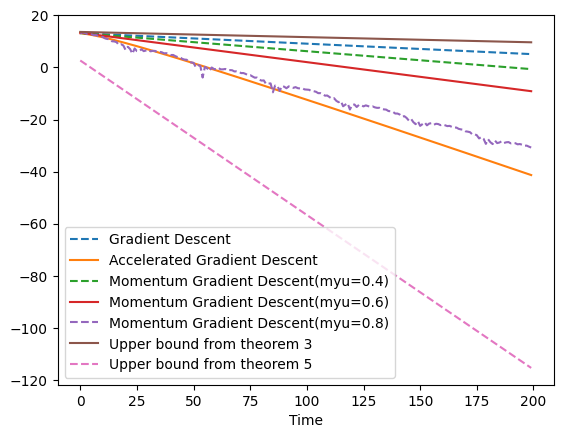

In [48]:
plt.plot(np.log(f_gd_50),label="Gradient Descent",color='#1f77b4',linestyle='--')
plt.plot(np.log(f_agd_50),label="Accelerated Gradient Descent" ,color='#ff7f0e',linestyle = 'solid')
plt.plot(np.log(f_mgd_0_4_50),label="Momentum Gradient Descent(myu=0.4)" ,color='#2ca02c',linestyle='--')
plt.plot(np.log(f_mgd_0_6_50),label="Momentum Gradient Descent(myu=0.6)" ,color='#d62728',linestyle = 'solid')
plt.plot(np.log(f_mgd_0_8_50),label="Momentum Gradient Descent(myu=0.8)" ,color='#9467bd',linestyle='--')
plt.plot(np.log(upper_bound_thm3_50),label="Upper bound from theorem 3",color='#8c564b',linestyle='solid')
plt.plot(np.log(upper_bound_thm5_50),label="Upper bound from theorem 5",color='#e377c2',linestyle='--')
plt.legend()
plt.xlabel("Time")
plt.show()

## k = 5 and eta = 0.4<br>

In [49]:
k=5
eta = 0.4

In [50]:
beta = beta_smooth(x,k)
alpha = alpha_smooth(x,k)

Defining the naming by adding _eta at the end of the previouse variables and recalculating the new ones <br>

In [51]:
x_gd_eta ,f_gd_eta = gradient_descent(x,T,eta,k)
x_agd_eta ,f_agd_eta = accelerated_gradient_descent(x,T,beta,k)
x_mgd_0_4_eta, f_mgd_0_4_eta= momentum_gradient_descent(x,T,beta,k,0.4)
x_mgd_0_6_eta , f_mgd_0_6_eta = momentum_gradient_descent(x,T,beta,k,0.6)
x_mgd_0_8_eta , f_mgd_0_8_eta = momentum_gradient_descent(x,T,beta,k,0.8)
upper_bound_thm3_eta = np.exp((-time_array)/k) * func(x,k)
upper_bound_thm5_eta = (1+gamma_5) ** (-time_array) *((alpha+beta)/2) 

Plotting f(x_t_gd) , f(x_t_agd) , f(x_t_mgd) versus time or we can say iterates(T) <br>

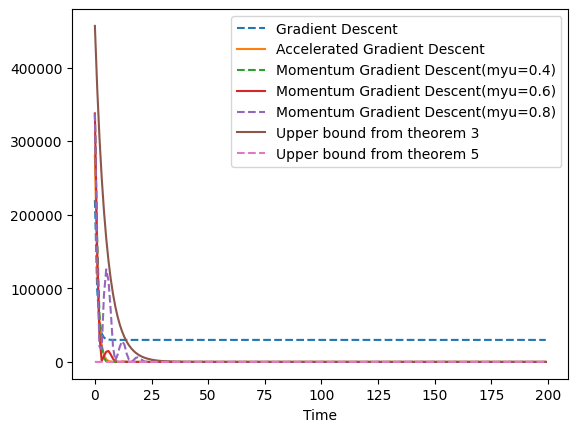

In [52]:
plt.plot(f_gd_eta,label="Gradient Descent",color='#1f77b4',linestyle='--')
plt.plot(f_agd_eta,label="Accelerated Gradient Descent" ,color='#ff7f0e',linestyle = 'solid')
plt.plot(f_mgd_0_4_eta,label="Momentum Gradient Descent(myu=0.4)" ,color='#2ca02c',linestyle='--')
plt.plot(f_mgd_0_6_eta,label="Momentum Gradient Descent(myu=0.6)" ,color='#d62728',linestyle = 'solid')
plt.plot(f_mgd_0_8_eta,label="Momentum Gradient Descent(myu=0.8)" ,color='#9467bd',linestyle='--')
plt.plot(upper_bound_thm3_eta,label="Upper bound from theorem 3",color='#8c564b',linestyle='solid')
plt.plot(upper_bound_thm5_eta,label="Upper bound from theorem 5",color='#e377c2',linestyle='--')
plt.legend()
plt.xlabel("Time")
plt.show()

Now plotting the ones in log <br>

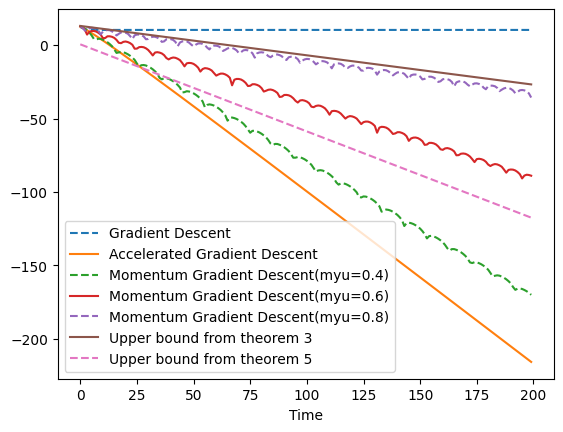

In [53]:
plt.plot(np.log(f_gd_eta),label="Gradient Descent",color='#1f77b4',linestyle='--')
plt.plot(np.log(f_agd_eta),label="Accelerated Gradient Descent" ,color='#ff7f0e',linestyle = 'solid')
plt.plot(np.log(f_mgd_0_4_eta),label="Momentum Gradient Descent(myu=0.4)" ,color='#2ca02c',linestyle='--')
plt.plot(np.log(f_mgd_0_6_eta),label="Momentum Gradient Descent(myu=0.6)" ,color='#d62728',linestyle = 'solid')
plt.plot(np.log(f_mgd_0_8_eta),label="Momentum Gradient Descent(myu=0.8)" ,color='#9467bd',linestyle='--')
plt.plot(np.log(upper_bound_thm3_eta),label="Upper bound from theorem 3",color='#8c564b',linestyle='solid')
plt.plot(np.log(upper_bound_thm5_eta),label="Upper bound from theorem 5",color='#e377c2',linestyle='--')
plt.legend()
plt.xlabel("Time")
plt.show()